<a href="https://colab.research.google.com/github/guss1976/TrabajoFinalCienciaDatos/blob/main/Trabajo_Final_Integrador_ver3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Abandono (Attrition) de Empleados en Recursos Humanos
### Proyecto Final Integrador — Diplomatura en Ciencia de Datos y Análisis Avanzado (UTN BA)

**Autores:** Paola Chabay, Gustavo Stampone, MPaz Gazzola Bascougnet, María Marta Caffaro

Este notebook implementa el plan de modelado y validación del proyecto: limpieza de datos, feature
engineering, un pipeline de preprocesamiento sin fuga de información, modelo baseline (Regresión
Logística), modelos de árbol (Random Forest y XGBoost), validación cruzada estratificada, ajuste de
umbral de decisión para el criterio de Recall > 0,75, comparación final de modelos contra el piso mínimo
de AUC-ROC ≥ 0,80 y de PR-AUC (relevante porque solo el 16,1% de los casos pertenece a la clase positiva),
una traducción de los resultados a un lenguaje simple para RRHH (Recall sobre el top 20% de riesgo),
análisis de equidad entre grupos y explicabilidad (SHAP) del modelo ganador.

**Nota:** el dataset (`WA_Fn-UseC_-HR-Employee-Attrition.csv`) es el dataset ficticio *IBM HR Analytics
Employee Attrition & Performance*, por lo que los resultados son válidos como prueba de concepto
metodológica y no deben generalizarse a una organización real.


## 1. Montaje de Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Selección del directorio de trabajo

Todo el proyecto (notebook, dataset, resultados y modelos exportados) se guarda dentro de la subcarpeta
**`Trabajo Final Integrador`** en el Google Drive del usuario. Si la carpeta no existe, se crea automáticamente.


In [ ]:
import os

BASE_DIR = '/content/drive/MyDrive/Ciencia de datos/TP visualizacion/Trabajo Final Integrador'
DATA_FILENAME = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
DATA_PATH = os.path.join(BASE_DIR, DATA_FILENAME)

os.makedirs(BASE_DIR, exist_ok=True)
os.chdir(BASE_DIR)

print(f'Directorio de trabajo actual: {os.getcwd()}')

if os.path.exists(DATA_PATH):
    print(f'Dataset encontrado: {DATA_PATH}')
else:
    print(f'ATENCIÓN: no se encontró el archivo en {DATA_PATH}.')
    print('Subí el CSV a esa carpeta de Drive antes de continuar (o ajustá DATA_PATH).')


Directorio de trabajo actual: /content/drive/MyDrive/Ciencia de datos/TP visualizacion/Trabajo Final Integrador
Dataset encontrado: /content/drive/MyDrive/Ciencia de datos/TP visualizacion/Trabajo Final Integrador/WA_Fn-UseC_-HR-Employee-Attrition.csv


## 3. Importación de librerías


In [ ]:
# XGBoost normalmente ya está instalado en Colab; se deja el instalador comentado por las dudas.
# %pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score,
                             average_precision_score, precision_recall_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_style('whitegrid')


## 4. Carga de datos


In [ ]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 5. Exploración inicial (EDA)

Se verifican los hallazgos declarados en la pre-entrega: tamaño del dataset, nulos, desbalanceo de clases y outliers.


In [ ]:
print('Filas x columnas:', df.shape)
print('Valores nulos totales:', df.isnull().sum().sum())
print()
print('Distribución de Attrition:')
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True).round(4) * 100)


Filas x columnas: (1470, 35)
Valores nulos totales: 0

Distribución de Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [ ]:
# Detección de outliers por rango intercuartílico (IQR)
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lim_inf) | (serie > lim_sup)).sum()

cols_revisar = ['MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears']
for col in cols_revisar:
    print(f'{col}: {contar_outliers_iqr(df[col])} outliers')


MonthlyIncome: 114 outliers
YearsAtCompany: 104 outliers
TotalWorkingYears: 63 outliers


In [ ]:
# Verificación de columnas con varianza cero (candidatas a eliminar)
for col in ['EmployeeCount', 'StandardHours', 'Over18']:
    print(col, '-> valores únicos:', df[col].unique())


EmployeeCount -> valores únicos: [1]
StandardHours -> valores únicos: [80]
Over18 -> valores únicos: ['Y']


### Validación de los outliers detectados (no se eliminan automáticamente)

Antes de decidir qué hacer con los outliers de `MonthlyIncome` y `YearsAtCompany`, se verifica si son valores
**válidos** (empleados senior reales) o errores de carga. Eliminarlos a ciegas por estar fuera del rango IQR
podría borrar justamente a los perfiles de mayor antigüedad/jerarquía, que son información relevante para el
problema de negocio.


In [ ]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# MonthlyIncome: ¿los outliers (sueldos muy altos) se concentran en niveles jerárquicos altos?
lo, hi = limites_iqr(df['MonthlyIncome'])
outliers_income = df[df['MonthlyIncome'] > hi]
print(f'Outliers de MonthlyIncome: {len(outliers_income)}')
print('Distribución por JobLevel:')
print(outliers_income['JobLevel'].value_counts())
print('Distribución por JobRole:')
print(outliers_income['JobRole'].value_counts())

# YearsAtCompany: ¿son consistentes con TotalWorkingYears (nadie puede tener más antigüedad
# en la empresa que experiencia laboral total)?
lo, hi = limites_iqr(df['YearsAtCompany'])
outliers_tenure = df[df['YearsAtCompany'] > hi]
inconsistentes = outliers_tenure[outliers_tenure['YearsAtCompany'] > outliers_tenure['TotalWorkingYears']]
print()
print(f'Outliers de YearsAtCompany: {len(outliers_tenure)}')
print(f'De esos, con YearsAtCompany > TotalWorkingYears (inconsistencia lógica): {len(inconsistentes)}')


Outliers de MonthlyIncome: 114
Distribución por JobLevel:
JobLevel
5    69
4    45
Name: count, dtype: int64
Distribución por JobRole:
JobRole
Manager              74
Research Director    40
Name: count, dtype: int64

Outliers de YearsAtCompany: 104
De esos, con YearsAtCompany > TotalWorkingYears (inconsistencia lógica): 0


**Conclusión de la validación:** los outliers de `MonthlyIncome` corresponden en su totalidad a empleados de
`JobLevel` 4 y 5 (manager y research director) — sueldos altos pero coherentes con el nivel jerárquico, no
errores de carga. Los outliers de `YearsAtCompany` no presentan ninguna inconsistencia lógica contra
`TotalWorkingYears`. **Decisión: no se eliminan estos valores.** Se los trata mediante escalado robusto
(`RobustScaler`, sección 10), que reduce su influencia sobre el modelo sin descartar información real de
empleados senior.


## 6. Limpieza de datos

Se eliminan `EmployeeCount`, `StandardHours` y `Over18` por varianza cero, y `EmployeeNumber` por ser un
identificador sin valor predictivo (evita fuga de información / cuasi-identificación de un empleado puntual).


In [ ]:
cols_eliminar = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=cols_eliminar)
print('Columnas restantes:', df.shape[1])
df.columns.tolist()


Columnas restantes: 31


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## 7. Feature engineering

Se agregan variables derivadas para capturar señales que las columnas originales no expresan directamente,
en línea con la hipótesis de trabajo (carga laboral, trayectoria y equilibrio vida-trabajo). Todas se
construyen antes del split para describirlas, pero se calculan con operaciones fila a fila (no usan
estadísticos agregados del dataset), por lo que no introducen fuga de información entre train y test:

- **`IngresoPorAnioExperiencia`**: `MonthlyIncome / (TotalWorkingYears + 1)`. Aproxima si el ingreso actual
  está por encima o por debajo de lo esperable para la experiencia acumulada.
- **`RatioAntiguedadEmpresa`**: `YearsAtCompany / (TotalWorkingYears + 1)`. Qué proporción de toda su carrera
  laboral transcurrió en esta empresa (cercano a 1 = toda su carrera fue acá).
- **`RatioEstancamientoPromocion`**: `YearsSinceLastPromotion / (YearsAtCompany + 1)`. Señal de estancamiento
  relativo en la carrera dentro de la empresa.
- **`RatioAntiguedadConManager`**: `YearsWithCurrManager / (YearsAtCompany + 1)`. Estabilidad del vínculo con
  el manager actual en relación a la antigüedad total.
- **`RotacionLaboralPrevia`**: `NumCompaniesWorked / (TotalWorkingYears + 1)`. Frecuencia histórica de cambio
  de empleo (a mayor valor, historial más "job-hopper").
- **`IndiceSatisfaccionGeneral`**: promedio de `JobSatisfaction`, `EnvironmentSatisfaction`,
  `RelationshipSatisfaction` y `WorkLifeBalance`. Compacta cuatro variables de satisfacción/equilibrio
  correlacionadas en un único índice.

El `+1` en los denominadores evita divisiones por cero para empleados sin antigüedad o sin promociones previas.


In [ ]:
df['IngresoPorAnioExperiencia'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['RatioAntiguedadEmpresa'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['RatioEstancamientoPromocion'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['RatioAntiguedadConManager'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)
df['RotacionLaboralPrevia'] = df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)
df['IndiceSatisfaccionGeneral'] = df[['JobSatisfaction', 'EnvironmentSatisfaction',
                                      'RelationshipSatisfaction', 'WorkLifeBalance']].mean(axis=1)

nuevas_features = ['IngresoPorAnioExperiencia', 'RatioAntiguedadEmpresa', 'RatioEstancamientoPromocion',
                    'RatioAntiguedadConManager', 'RotacionLaboralPrevia', 'IndiceSatisfaccionGeneral']
df[nuevas_features].describe()


,IngresoPorAnioExperiencia,RatioAntiguedadEmpresa,RatioEstancamientoPromocion,RatioAntiguedadConManager,RotacionLaboralPrevia,IndiceSatisfaccionGeneral
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,587.575385,0.581830,0.236458,0.465510,0.278598,2.730952
std,284.650784,0.284476,0.269358,0.276763,0.294419,0.505815
min,95.285714,0.000000,0.000000,0.000000,0.000000,1.000000
25%,374.232143,0.368421,0.000000,0.285714,0.090909,2.500000
50%,549.220648,0.636364,0.142857,0.500000,0.176471,2.750000
75%,738.303846,0.833333,0.428571,0.666667,0.390700,3.000000
max,1904.000000,0.975610,0.916667,0.894737,2.250000,4.000000


## 8. Definición de variables predictoras (X) y objetivo (y)

Las variables nuevas creadas en el paso anterior son numéricas, así que se incorporan automáticamente a
`num_cols` sin pasos adicionales.


In [ ]:
y = (df['Attrition'] == 'Yes').astype(int)
X = df.drop(columns=['Attrition'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print('Variables categóricas:', cat_cols)
print()
print('Variables numéricas:', num_cols)


Variables categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Variables numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IngresoPorAnioExperiencia', 'RatioAntiguedadEmpresa', 'RatioEstancamientoPromocion', 'RatioAntiguedadConManager', 'RotacionLaboralPrevia', 'IndiceSatisfaccionGeneral']


## 9. División train/test estratificada

80% entrenamiento / 20% test, estratificado por `Attrition` para conservar la proporción 83,9% / 16,1% en ambos conjuntos.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, '- tasa positiva:', y_train.mean().round(4))
print('Test :', X_test.shape, '- tasa positiva:', y_test.mean().round(4))


Train: (1176, 36) - tasa positiva: 0.1616
Test : (294, 36) - tasa positiva: 0.1599


## 10. Pipeline de preprocesamiento

One-Hot Encoding para categóricas y escalado robusto (RobustScaler, menos sensible a outliers) para numéricas.
Al ir dentro de un `Pipeline` de scikit-learn junto con el modelo, el ajuste (fit) del encoder/scaler se hace
únicamente sobre el fold de entrenamiento en cada validación, evitando fuga de información.


In [ ]:
preprocesador = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', RobustScaler(), num_cols)
])


## 11. Función auxiliar de evaluación

Centraliza el cálculo de métricas para poder comparar baseline, Random Forest y XGBoost de forma consistente.


In [ ]:
resultados = []  # acá se acumulan las métricas de cada modelo para la tabla comparativa final

def evaluar_modelo(nombre, y_true, y_proba, threshold=0.5, guardar=True):
    y_pred = (y_proba >= threshold).astype(int)
    tasa_positiva = np.mean(y_true)  # nivel de PR-AUC que lograría un modelo sin ninguna capacidad predictiva
    metrics = {
        'Modelo': nombre,
        'Umbral': threshold,
        'Recall': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
    }
    print(f"--- {nombre} (umbral={threshold:.2f}) ---")
    for k, v in metrics.items():
        if k not in ('Modelo', 'Umbral'):
            print(f'{k}: {v:.3f}')
    print(f'(referencia: un modelo sin capacidad predictiva tendria PR-AUC ~= {tasa_positiva:.3f}, la tasa base de Attrition="Yes")')
    print()
    print(classification_report(y_true, y_pred, target_names=['No', 'Yes']))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(cmap='Blues')
    plt.title(f'Matriz de confusión — {nombre}')
    plt.show()
    if guardar:
        resultados.append(metrics)
    return metrics

def umbral_para_recall_objetivo(y_true, y_proba, recall_objetivo=0.75):
    """Busca el umbral de decisión más alto que todavía alcanza el recall objetivo
    (maximiza precisión sujeto a Recall >= recall_objetivo)."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    candidatos = [(t, p) for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds) if r >= recall_objetivo]
    if not candidatos:
        print('Ningún umbral alcanza el recall objetivo; se devuelve 0.0 (marca a todos como positivos)')
        return 0.0
    umbral_optimo = max(candidatos, key=lambda x: x[1])[0]
    return umbral_optimo


## 12. Modelo baseline: Regresión Logística

Se usa `class_weight='balanced'` para compensar el desbalanceo de clases (83,9% / 16,1%) sin necesidad de re-muestrear.
La corrida a umbral 0.5 es solo de referencia (`guardar=False`); el modelo se compara formalmente ya con el umbral
ajustado al criterio de Recall > 0,75 en la próxima celda.


--- Regresión Logística (umbral 0.5, referencia) (umbral=0.50) ---
Recall: 0.660
Precision: 0.388
F1: 0.488
AUC-ROC: 0.808
PR-AUC: 0.558
(referencia: un modelo sin capacidad predictiva tendria PR-AUC ~= 0.160, la tasa base de Attrition="Yes")

              precision    recall  f1-score   support

          No       0.93      0.80      0.86       247
         Yes       0.39      0.66      0.49        47

    accuracy                           0.78       294
   macro avg       0.66      0.73      0.67       294
weighted avg       0.84      0.78      0.80       294



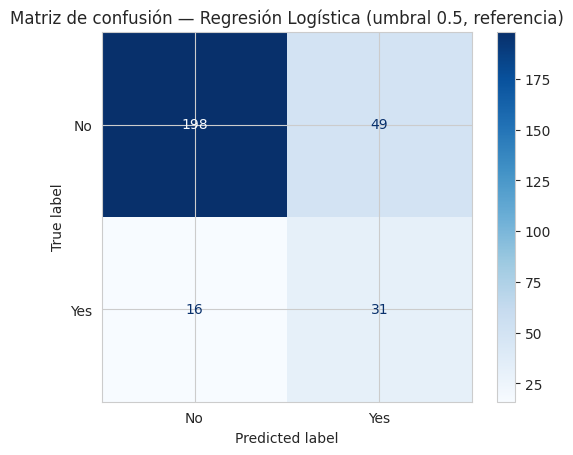

In [ ]:
pipe_logreg = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

pipe_logreg.fit(X_train, y_train)
proba_logreg = pipe_logreg.predict_proba(X_test)[:, 1]

_ = evaluar_modelo('Regresión Logística (umbral 0.5, referencia)', y_test, proba_logreg, threshold=0.5, guardar=False)


## 13. Ajuste de umbral de decisión (criterio: Recall > 0,75)

El umbral por defecto (0.5) no necesariamente cumple el criterio de éxito de Recall > 0,75 definido para el
proyecto. Se busca el umbral que cumple ese piso de Recall maximizando la precisión posible, y esta versión
es la que queda registrada en la tabla comparativa final.


Umbral seleccionado para Recall >= 0.75: 0.373
--- Regresión Logística (umbral=0.37) ---
Recall: 0.766
Precision: 0.324
F1: 0.456
AUC-ROC: 0.808
PR-AUC: 0.558
(referencia: un modelo sin capacidad predictiva tendria PR-AUC ~= 0.160, la tasa base de Attrition="Yes")

              precision    recall  f1-score   support

          No       0.94      0.70      0.80       247
         Yes       0.32      0.77      0.46        47

    accuracy                           0.71       294
   macro avg       0.63      0.73      0.63       294
weighted avg       0.84      0.71      0.74       294



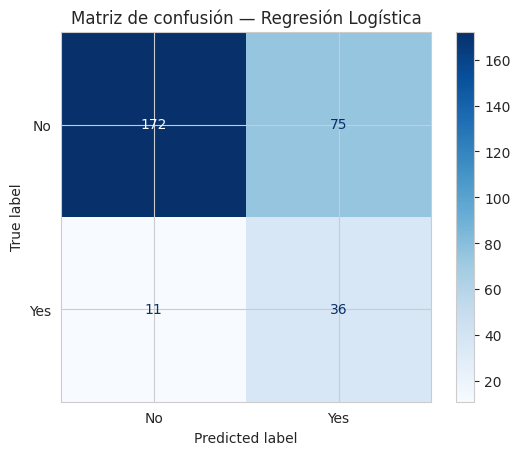

In [ ]:
umbral_logreg = umbral_para_recall_objetivo(y_test, proba_logreg, recall_objetivo=0.75)
print(f'Umbral seleccionado para Recall >= 0.75: {umbral_logreg:.3f}')

_ = evaluar_modelo('Regresión Logística', y_test, proba_logreg, threshold=umbral_logreg)


## 14. Validación cruzada estratificada (K-Fold, k=5)

Valida que el desempeño del baseline sea estable y no dependa de la partición particular de train/test.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['recall', 'precision', 'f1', 'roc_auc', 'average_precision']

cv_resultados = cross_validate(pipe_logreg, X_train, y_train, cv=cv, scoring=scoring)

print('Resultados de validación cruzada estratificada (k=5) — Regresión Logística:')
for metrica in scoring:
    valores = cv_resultados[f'test_{metrica}']
    print(f'{metrica}: media={valores.mean():.3f}  (+/- {valores.std():.3f})')


Resultados de validación cruzada estratificada (k=5) — Regresión Logística:
recall: media=0.742  (+/- 0.061)
precision: media=0.380  (+/- 0.037)
f1: media=0.500  (+/- 0.031)
roc_auc: media=0.831  (+/- 0.023)
average_precision: media=0.625  (+/- 0.060)


## 15. Ajuste de hiperparámetros (opcional)

La búsqueda de hiperparámetros vía `GridSearchCV` puede tardar varios minutos según el tamaño de la grilla.
Esta celda pregunta de forma interactiva si se desea ejecutarla; si se responde que no, Random Forest y
XGBoost se entrenan con hiperparámetros por defecto razonables (celdas siguientes).

In [ ]:
#respuesta = input('¿Querés ejecutar la búsqueda de hiperparámetros (GridSearchCV) para Random Forest y XGBoost? (s/n): ')
#USAR_GRID_SEARCH = respuesta.strip().lower().startswith('s')
#print('Búsqueda de hiperparámetros:', 'SI' if USAR_GRID_SEARCH else 'NO (se usan valores por defecto)')
USAR_GRID_SEARCH = True
print('Búsqueda de hiperparámetros: SI')

Búsqueda de hiperparámetros: SI


In [ ]:
# Grillas de hiperparámetros propuestas.
# Scoring = 'roc_auc': es consistente con el criterio de éxito "AUC-ROC >= 0.80 como piso mínimo" del
# plan de modelado; el umbral de decisión para Recall > 0.75 se ajusta después, por separado, con
# umbral_para_recall_objetivo().

grid_rf = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 8, 16],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
}

grid_xgb = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.8, 1.0],
}


## 16. Modelo Random Forest


Mejores hiperparámetros (Random Forest): {'clf__max_depth': 16, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
Umbral seleccionado para Recall >= 0.75: 0.200
--- Random Forest (umbral=0.20) ---
Recall: 0.766
Precision: 0.333
F1: 0.465
AUC-ROC: 0.759
PR-AUC: 0.401
(referencia: un modelo sin capacidad predictiva tendria PR-AUC ~= 0.160, la tasa base de Attrition="Yes")

              precision    recall  f1-score   support

          No       0.94      0.71      0.81       247
         Yes       0.33      0.77      0.46        47

    accuracy                           0.72       294
   macro avg       0.64      0.74      0.64       294
weighted avg       0.84      0.72      0.75       294



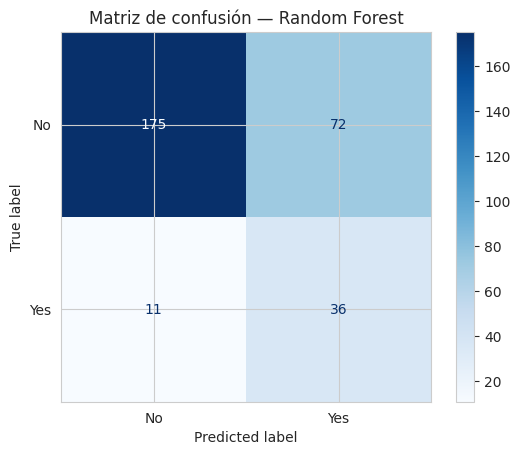

In [ ]:
pipe_rf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

if USAR_GRID_SEARCH:
    busqueda_rf = GridSearchCV(pipe_rf, grid_rf, scoring='roc_auc', cv=cv, n_jobs=-1)
    busqueda_rf.fit(X_train, y_train)
    pipe_rf = busqueda_rf.best_estimator_
    print('Mejores hiperparámetros (Random Forest):', busqueda_rf.best_params_)
else:
    pipe_rf.set_params(clf__n_estimators=300, clf__max_depth=12, clf__min_samples_leaf=2)
    pipe_rf.fit(X_train, y_train)

proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
umbral_rf = umbral_para_recall_objetivo(y_test, proba_rf, recall_objetivo=0.75)
print(f'Umbral seleccionado para Recall >= 0.75: {umbral_rf:.3f}')
_ = evaluar_modelo('Random Forest', y_test, proba_rf, threshold=umbral_rf)


## 17. Modelo XGBoost


Mejores hiperparámetros (XGBoost): {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 400, 'clf__subsample': 0.8}
Umbral seleccionado para Recall >= 0.75: 0.150
--- XGBoost (umbral=0.15) ---
Recall: 0.766
Precision: 0.295
F1: 0.426
AUC-ROC: 0.763
PR-AUC: 0.493
(referencia: un modelo sin capacidad predictiva tendria PR-AUC ~= 0.160, la tasa base de Attrition="Yes")

              precision    recall  f1-score   support

          No       0.94      0.65      0.77       247
         Yes       0.30      0.77      0.43        47

    accuracy                           0.67       294
   macro avg       0.62      0.71      0.60       294
weighted avg       0.83      0.67      0.71       294



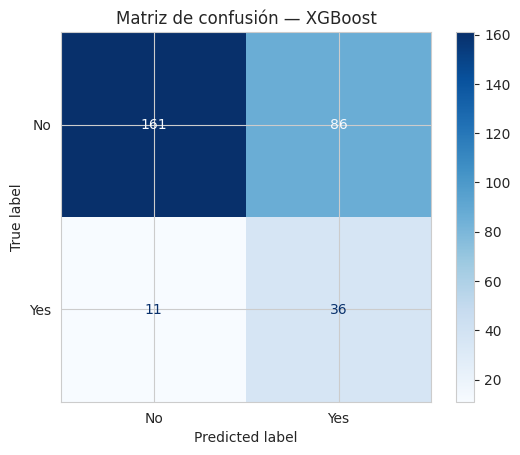

In [ ]:
# scale_pos_weight compensa el desbalanceo de clases en XGBoost (equivalente a class_weight='balanced')
ratio_negativo_positivo = (y_train == 0).sum() / (y_train == 1).sum()

pipe_xgb = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clf', XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        scale_pos_weight=ratio_negativo_positivo,
    ))
])

if USAR_GRID_SEARCH:
    busqueda_xgb = GridSearchCV(pipe_xgb, grid_xgb, scoring='roc_auc', cv=cv, n_jobs=-1)
    busqueda_xgb.fit(X_train, y_train)
    pipe_xgb = busqueda_xgb.best_estimator_
    print('Mejores hiperparámetros (XGBoost):', busqueda_xgb.best_params_)
else:
    pipe_xgb.set_params(clf__n_estimators=300, clf__max_depth=4, clf__learning_rate=0.05)
    pipe_xgb.fit(X_train, y_train)

proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
umbral_xgb = umbral_para_recall_objetivo(y_test, proba_xgb, recall_objetivo=0.75)
print(f'Umbral seleccionado para Recall >= 0.75: {umbral_xgb:.3f}')
_ = evaluar_modelo('XGBoost', y_test, proba_xgb, threshold=umbral_xgb)


## 18. Comparación de modelos

Se compara Regresión Logística (baseline) contra Random Forest y XGBoost. Según el criterio definido para
el proyecto, los modelos de árbol deben **superar** el AUC-ROC del baseline (piso mínimo ~0,80), no solo igualarlo.


In [ ]:
tabla_comparativa = pd.DataFrame(resultados)[['Modelo', 'Umbral', 'Recall', 'Precision', 'F1', 'AUC-ROC', 'PR-AUC']]
tabla_comparativa = tabla_comparativa.round(3)
tabla_comparativa


,Modelo,Umbral,Recall,Precision,F1,AUC-ROC,PR-AUC
0,Regresión Logística,0.373,0.766,0.324,0.456,0.808,0.558
1,Random Forest,0.200,0.766,0.333,0.465,0.759,0.401
2,XGBoost,0.150,0.766,0.295,0.426,0.763,0.493


In [ ]:
auc_baseline = tabla_comparativa.loc[tabla_comparativa['Modelo'] == 'Regresión Logística', 'AUC-ROC'].values[0]
print(f'AUC-ROC del baseline (Regresión Logística): {auc_baseline:.3f}')
for _, fila in tabla_comparativa.iterrows():
    if fila['Modelo'] in ('Random Forest', 'XGBoost'):
        supera = 'SI supera' if fila['AUC-ROC'] > auc_baseline else 'NO supera'
        print(f"{fila['Modelo']}: AUC-ROC={fila['AUC-ROC']:.3f} -> {supera} al baseline")


AUC-ROC del baseline (Regresión Logística): 0.808
Random Forest: AUC-ROC=0.759 -> NO supera al baseline
XGBoost: AUC-ROC=0.763 -> NO supera al baseline


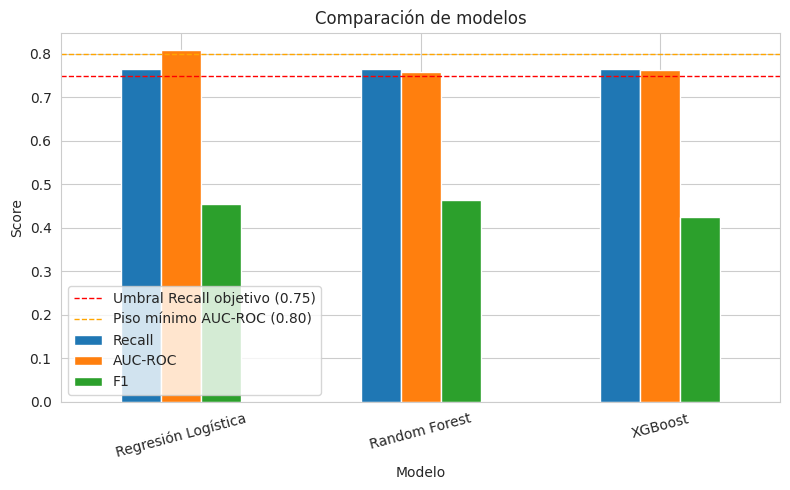

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
tabla_comparativa.set_index('Modelo')[['Recall', 'AUC-ROC', 'F1']].plot(kind='bar', ax=ax)
ax.axhline(0.75, color='red', linestyle='--', linewidth=1, label='Umbral Recall objetivo (0.75)')
ax.axhline(0.80, color='orange', linestyle='--', linewidth=1, label='Piso mínimo AUC-ROC (0.80)')
plt.title('Comparación de modelos')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()


## 18b. Traducción a un lenguaje simple para RRHH

Recall, Precision y AUC son métricas técnicas. La pregunta que realmente le importa a RRHH es más simple:
*"si revisamos solo al 20% de empleados con mayor riesgo predicho, ¿qué porcentaje de las renuncias reales
estamos detectando?"* Eso es lo que calcula `recall_en_top_k` — no depende de ningún umbral de probabilidad,
solo de ordenar a los empleados de mayor a menor riesgo y mirar los primeros K%.


In [ ]:
def recall_en_top_k(y_true, y_proba, k=0.20):
    y_true_arr = np.asarray(y_true)
    n = len(y_true_arr)
    n_top = int(np.ceil(n * k))
    orden_por_riesgo = np.argsort(-y_proba)  # de mayor a menor riesgo predicho
    idx_top = orden_por_riesgo[:n_top]
    renuncias_totales = y_true_arr.sum()
    renuncias_detectadas = y_true_arr[idx_top].sum()
    return {
        '% de plantilla revisada': f'{k:.0%}',
        'Empleados revisados': n_top,
        'Renuncias reales en el test': int(renuncias_totales),
        'Renuncias detectadas en ese grupo': int(renuncias_detectadas),
        'Recall en el Top-K%': round(renuncias_detectadas / renuncias_totales, 3) if renuncias_totales else np.nan,
    }

for nombre, proba in [('Regresión Logística', proba_logreg), ('Random Forest', proba_rf), ('XGBoost', proba_xgb)]:
    resultado_k = recall_en_top_k(y_test, proba, k=0.20)
    print(f'--- {nombre} ---')
    for k_, v_ in resultado_k.items():
        print(f'  {k_}: {v_}')
    print()


--- Regresión Logística ---
  % de plantilla revisada: 20%
  Empleados revisados: 59
  Renuncias reales en el test: 47
  Renuncias detectadas en ese grupo: 28
  Recall en el Top-K%: 0.596

--- Random Forest ---
  % de plantilla revisada: 20%
  Empleados revisados: 59
  Renuncias reales en el test: 47
  Renuncias detectadas en ese grupo: 24
  Recall en el Top-K%: 0.511

--- XGBoost ---
  % de plantilla revisada: 20%
  Empleados revisados: 59
  Renuncias reales en el test: 47
  Renuncias detectadas en ese grupo: 23
  Recall en el Top-K%: 0.489



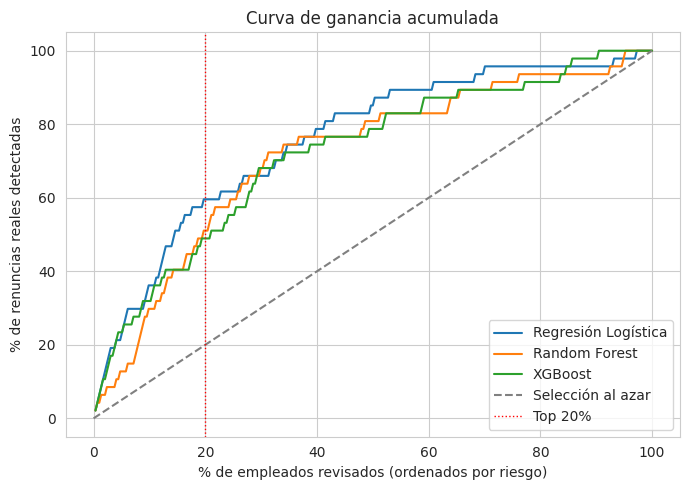

In [ ]:
# Curva de ganancia acumulada (cumulative gains): cuánto recall se logra a medida que se
# revisa un porcentaje creciente de la plantilla, ordenada de mayor a menor riesgo.
def curva_ganancia_acumulada(y_true, y_proba, nombre_modelo):
    y_true_arr = np.asarray(y_true)
    orden = np.argsort(-y_proba)
    y_ordenado = y_true_arr[orden]
    pct_revisado = np.arange(1, len(y_true_arr) + 1) / len(y_true_arr)
    recall_acumulado = np.cumsum(y_ordenado) / y_true_arr.sum()
    plt.plot(pct_revisado * 100, recall_acumulado * 100, label=nombre_modelo)

plt.figure(figsize=(7, 5))
for nombre, proba in [('Regresión Logística', proba_logreg), ('Random Forest', proba_rf), ('XGBoost', proba_xgb)]:
    curva_ganancia_acumulada(y_test, proba, nombre)
plt.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Selección al azar')
plt.axvline(20, color='red', linestyle=':', linewidth=1, label='Top 20%')
plt.xlabel('% de empleados revisados (ordenados por riesgo)')
plt.ylabel('% de renuncias reales detectadas')
plt.title('Curva de ganancia acumulada')
plt.legend()
plt.tight_layout()
plt.show()


## 19. Importancia de variables

Permite contrastar empíricamente la hipótesis de trabajo (horas extras, ingreso, distancia, antigüedad,
satisfacción/equilibrio, y las variables derivadas del feature engineering) con lo que el modelo efectivamente
usa para predecir.


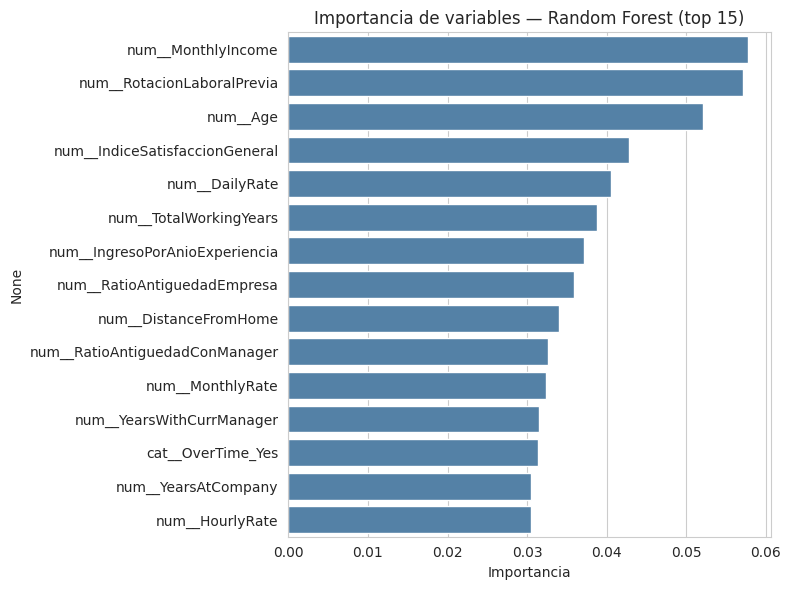

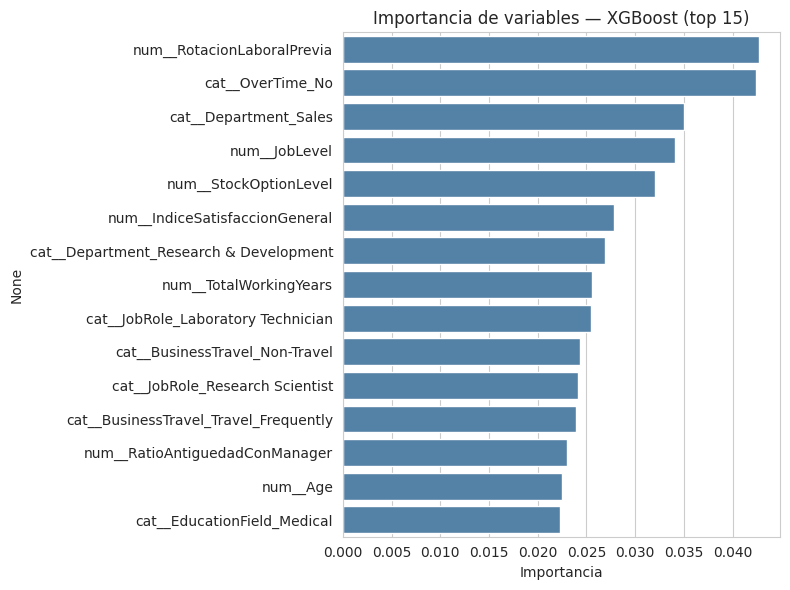

In [ ]:
def graficar_importancias(pipe, nombre_modelo, top_n=15):
    modelo = pipe.named_steps['clf']
    nombres_features = pipe.named_steps['preprocesador'].get_feature_names_out()
    importancias = pd.Series(modelo.feature_importances_, index=nombres_features)
    importancias = importancias.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importancias.values, y=importancias.index, color='steelblue')
    plt.title(f'Importancia de variables — {nombre_modelo} (top {top_n})')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.show()

graficar_importancias(pipe_rf, 'Random Forest')
graficar_importancias(pipe_xgb, 'XGBoost')


## 20. Selección del modelo a analizar

Las secciones de equidad y explicabilidad (SHAP) trabajan sobre **un** modelo — por defecto, el ganador según
AUC-ROC en la tabla comparativa. Para forzar manualmente otro modelo, alcanza con cambiar `MODELO_A_ANALIZAR`
por `'Regresión Logística'`, `'Random Forest'` o `'XGBoost'` y volver a correr las celdas de abajo.


In [ ]:
MODELO_A_ANALIZAR = 'auto'  # 'auto' = usa el ganador por AUC-ROC; o poner el nombre exacto de otro modelo

pipes_entrenados = {
    'Regresión Logística': pipe_logreg,
    'Random Forest': pipe_rf,
    'XGBoost': pipe_xgb,
}
proba_por_modelo = {
    'Regresión Logística': proba_logreg,
    'Random Forest': proba_rf,
    'XGBoost': proba_xgb,
}
umbral_por_modelo = {
    'Regresión Logística': umbral_logreg,
    'Random Forest': umbral_rf,
    'XGBoost': umbral_xgb,
}

ganador_nombre = tabla_comparativa.sort_values('AUC-ROC', ascending=False).iloc[0]['Modelo']
nombre_modelo_analizado = ganador_nombre if MODELO_A_ANALIZAR == 'auto' else MODELO_A_ANALIZAR
pipe_analizado = pipes_entrenados[nombre_modelo_analizado]
proba_analizada = proba_por_modelo[nombre_modelo_analizado]
umbral_analizado = umbral_por_modelo[nombre_modelo_analizado]

origen = 'ganador automático por AUC-ROC' if MODELO_A_ANALIZAR == 'auto' else 'elegido manualmente'
print(f'Modelo analizado en equidad y SHAP: {nombre_modelo_analizado} ({origen})')


Modelo analizado en equidad y SHAP: Regresión Logística (ganador automático por AUC-ROC)


## 21. Análisis de equidad entre grupos

Se compara el desempeño del modelo analizado (Recall y Precision) entre subgrupos de `Gender`,
`MaritalStatus` y rangos etarios, tal como se identificó en los riesgos del proyecto. El objetivo es
detectar si el modelo falla sistemáticamente más para algún grupo, no dar un veredicto definitivo: con un
conjunto de test de ~294 empleados, los subgrupos quedan chicos y las diferencias pueden deberse a ruido,
no necesariamente a un sesgo real del modelo.


In [ ]:
y_pred_analizado = (proba_analizada >= umbral_analizado).astype(int)

def metricas_por_grupo(y_true, y_pred, grupo, nombre_grupo):
    tabla = pd.DataFrame({'y_true': np.asarray(y_true), 'y_pred': y_pred, 'grupo': np.asarray(grupo)})
    filas = []
    for valor, sub in tabla.groupby('grupo', observed=True):
        filas.append({
            nombre_grupo: valor,
            'N': len(sub),
            'Tasa real de Attrition': round(sub['y_true'].mean(), 3),
            'Recall': round(recall_score(sub['y_true'], sub['y_pred'], zero_division=0), 3),
            'Precision': round(precision_score(sub['y_true'], sub['y_pred'], zero_division=0), 3),
        })
    return pd.DataFrame(filas)

print('--- Por Gender ---')
display(metricas_por_grupo(y_test, y_pred_analizado, X_test['Gender'], 'Gender'))

print('--- Por MaritalStatus ---')
display(metricas_por_grupo(y_test, y_pred_analizado, X_test['MaritalStatus'], 'MaritalStatus'))

bins_edad = [17, 29, 39, 49, 61]
etiquetas_edad = ['18-29', '30-39', '40-49', '50+']
grupo_edad = pd.cut(X_test['Age'], bins=bins_edad, labels=etiquetas_edad, include_lowest=True)
print('--- Por rango etario ---')
display(metricas_por_grupo(y_test, y_pred_analizado, grupo_edad, 'Rango etario'))


--- Por Gender ---


,Gender,N,Tasa real de Attrition,Recall,Precision
0,Female,116,0.138,0.750,0.279
1,Male,178,0.174,0.774,0.353


--- Por MaritalStatus ---


,MaritalStatus,N,Tasa real de Attrition,Recall,Precision
0,Divorced,64,0.062,1.000,0.286
1,Married,133,0.135,0.722,0.289
2,Single,97,0.258,0.760,0.365


--- Por rango etario ---


,Rango etario,N,Tasa real de Attrition,Recall,Precision
0,18-29,68,0.250,0.882,0.395
1,30-39,125,0.112,0.857,0.240
2,40-49,67,0.119,0.750,0.353
3,50+,34,0.235,0.375,0.500


## 22. Explicabilidad del modelo ganador (SHAP)

Se calculan valores SHAP sobre el modelo seleccionado en la sección 20 (por defecto, el ganador por AUC-ROC).
`shap.Explainer` elige automáticamente el algoritmo adecuado según el tipo de modelo (lineal para la Regresión
Logística, basado en árboles para Random Forest/XGBoost).


In [ ]:
# SHAP no viene preinstalado en todos los entornos de Colab
try:
    import shap
except ImportError:
    %pip install -q shap
    import shap

shap.initjs()


In [ ]:
nombres_features = pipe_analizado.named_steps['preprocesador'].get_feature_names_out()
X_test_transformado = pipe_analizado.named_steps['preprocesador'].transform(X_test)
if hasattr(X_test_transformado, 'toarray'):
    X_test_transformado = X_test_transformado.toarray()
X_test_transformado = pd.DataFrame(X_test_transformado, columns=nombres_features)

explainer = shap.Explainer(pipe_analizado.named_steps['clf'], X_test_transformado)
shap_values = explainer(X_test_transformado)

print(f'Valores SHAP calculados para: {nombre_modelo_analizado}')


Valores SHAP calculados para: Regresión Logística


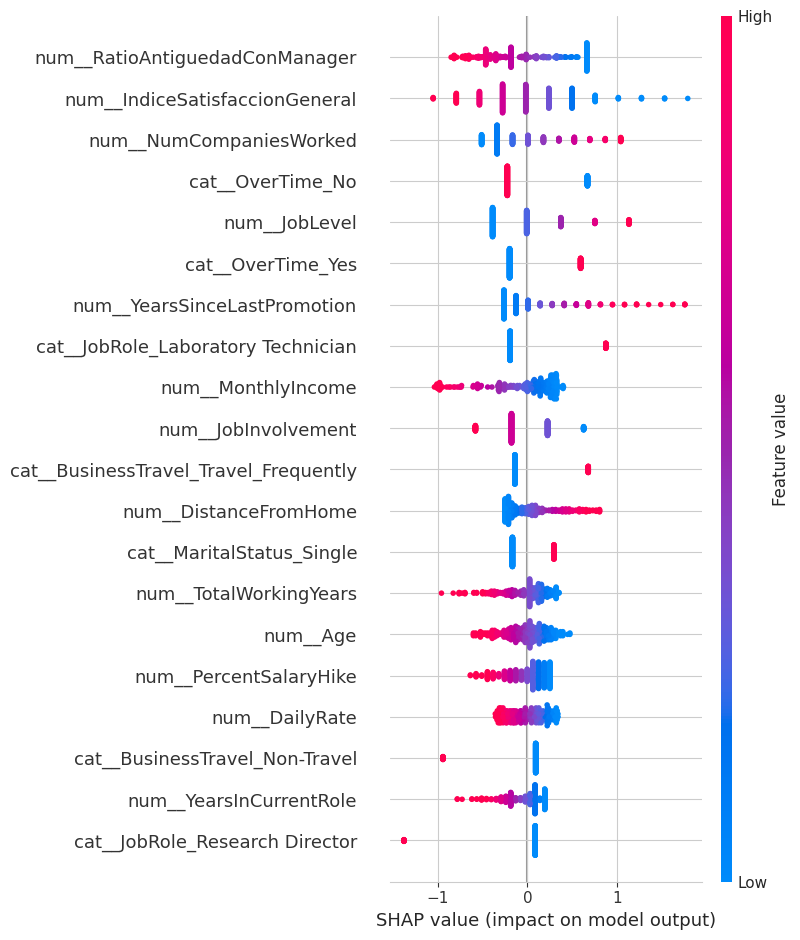

In [ ]:
shap.summary_plot(shap_values, X_test_transformado, show=True)


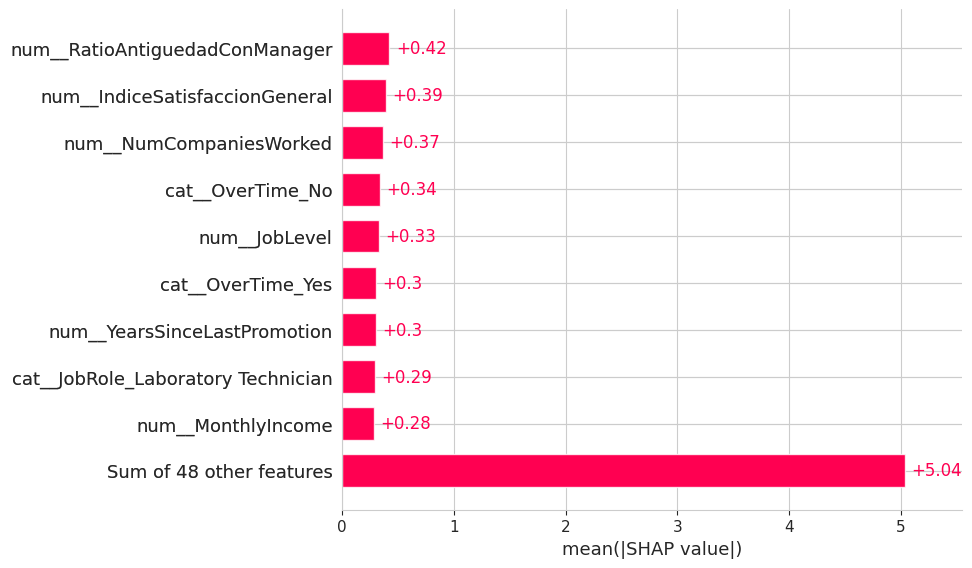

In [ ]:
shap.plots.bar(shap_values, show=True)


## 23. Guardado de resultados y modelos

Se guardan la tabla comparativa y los modelos entrenados dentro de la carpeta `Trabajo Final Integrador` en Drive.


In [ ]:
tabla_comparativa.to_csv(os.path.join(BASE_DIR, 'comparacion_modelos.csv'), index=False)

joblib.dump(pipe_logreg, os.path.join(BASE_DIR, 'modelo_baseline_logreg.joblib'))
joblib.dump(pipe_rf, os.path.join(BASE_DIR, 'modelo_random_forest.joblib'))
joblib.dump(pipe_xgb, os.path.join(BASE_DIR, 'modelo_xgboost.joblib'))

print('Resultados y modelos guardados en:', BASE_DIR)


Resultados y modelos guardados en: /content/drive/MyDrive/Ciencia de datos/TP visualizacion/Trabajo Final Integrador


## 24. Notas y próximos pasos

- Este notebook ya cubre feature engineering, comparación de modelos con validación cruzada estratificada,
  ajuste de umbral, PR-AUC, una métrica de negocio simple (Recall en el top 20% de riesgo), validación de
  outliers (no se eliminan sin verificar), análisis de equidad entre grupos y explicabilidad (SHAP) del
  modelo ganador.
- El análisis de equidad de la sección 21 es descriptivo, no concluyente: con un test set de ~294 filas,
  conviene revalidar cualquier brecha encontrada con un dataset más grande antes de sacar conclusiones firmes.
- Pendiente para una eventual implementación real: la validación del KPI de negocio (reducción del 15% en
  la rotación) y la comparación contra instrumentos de clima laboral (Gallup Q12) requieren datos
  longitudinales reales y un experimento A/B en producción, fuera del alcance de este notebook.
- También quedaría pendiente, ya en producción: monitoreo de *data drift* (si el perfil de los empleados
  cambia con el tiempo, el modelo puede perder vigencia) y un proceso definido de reentrenamiento periódico.
